# Computer Exercise 13.11 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.11 Advanced Global Optimization — *Particle Swarm Optimization*
> **풀이 일자**: Day 56
> **언어**: Python 3 (NumPy / Matplotlib)

## 1. 문제 (원문)

> **1.** Implement the **particle swarm optimization (PSO)** method for minimizing a function of
> several variables. Test it on the strongly **multimodal** *Rastrigin* function in two dimensions.
> Study how the **inertia weight** $w$ and the **swarm topology** (a fully connected *global-best*
> swarm versus a *ring* neighborhood) influence the probability of locating the global minimum and
> the speed of convergence. Report success rates over many random restarts and compare the two
> topologies on the same function-evaluation budget.

### 한국어 풀이용 정리
개체군 기반 전역 최적화의 또 다른 대표주자인 **입자군집최적화(PSO)** 를 직접 구현한다. 각 입자는
자기 최선($\mathbf{p}_i$)과 이웃 최선($\mathbf{g}$)에 끌리는 속도 갱신으로 탐색공간을 누빈다. 다봉
함수(Rastrigin)에서 **관성가중치 $w$** 와 **군집 위상**(전 입자가 연결된 *global-best* vs 고리형
*ring*)이 전역최소 도달 확률·수렴 속도에 주는 영향을 동일 예산에서 비교하고, 다중 재시작으로
성공률을 보고한다.

## 2. 수학적 배경

### 2.1 속도·위치 갱신
입자 $i$ 의 위치 $\mathbf{x}_i$, 속도 $\mathbf{v}_i$, 개인 최선 $\mathbf{p}_i$, 이웃 최선
$\mathbf{g}_i$ 에 대해 표준 PSO 갱신은

$$
\mathbf{v}_i \leftarrow w\,\mathbf{v}_i
\;+\; c_1\, r_1 \odot(\mathbf{p}_i-\mathbf{x}_i)
\;+\; c_2\, r_2 \odot(\mathbf{g}_i-\mathbf{x}_i),
\qquad
\mathbf{x}_i \leftarrow \mathbf{x}_i+\mathbf{v}_i,
$$

여기서 $r_1,r_2\sim\mathcal{U}(0,1)^d$ 는 성분별 난수, $\odot$ 는 성분별 곱이다. $c_1$(인지)·
$c_2$(사회) 는 가속상수.

### 2.2 관성가중치 $w$ 의 역할
$w$ 는 이전 속도를 얼마나 유지할지 정한다. **큰 $w$** 는 관성이 커 **탐색(exploration)**, **작은 $w$** 는
빠른 감쇠로 **활용(exploitation)** 에 유리하다. 수렴을 위한 고전적 안정성 조건(Clerc–Kennedy)은 대략

$$
w < 1, \qquad w > \tfrac{1}{2}(c_1+c_2)-1 .
$$

흔히 $w$ 를 0.9→0.4 로 **선형 감소**시켜 초기에 넓게 탐색하다 후기에 수렴시킨다.

### 2.3 위상(topology)
- **global-best (gbest)**: 모든 입자가 단 하나의 전역최선 $\mathbf{g}$ 를 공유 → 정보 전파가 빨라
  **수렴은 빠르나** 조기수렴(premature convergence) 위험.
- **ring (lbest)**: 각 입자는 좌우 이웃만 본다 → 정보가 천천히 퍼져 **다양성 유지**, 다봉 함수에서
  국소최소 탈출에 유리할 수 있다.

### 2.4 시험함수 (Rastrigin)
$$
f(\mathbf{x}) = 10\,d + \sum_{i=1}^{d}\bigl[x_i^2 - 10\cos(2\pi x_i)\bigr],
\qquad \mathbf{x}^\*=\mathbf{0},\ f(\mathbf{x}^\*)=0 .
$$
$$\boxed{\;\text{PSO: } \mathbf{v}\leftarrow w\mathbf{v}+c_1r_1(\mathbf{p}-\mathbf{x})+c_2r_2(\mathbf{g}-\mathbf{x})\;\Rightarrow\;\text{군집 지능으로 전역최소 탐색}\;}$$

## 3. 풀이 흐름

1. **목적함수**: 2D Rastrigin, 탐색영역 $[-5.12,5.12]^2$, 속도 한계 $v_{\max}=0.2\cdot$범위.
2. **초기화**: $N$ 개 입자를 균등 난수로 배치, 속도는 작게.
3. **위상 함수**: gbest(전역 최선) / ring(좌우 이웃 최선) 두 가지 이웃 최선 계산기를 분리.
4. **PSO 루프**: 속도·위치 갱신 → 경계 clip → 개인/이웃 최선 갱신. $w$ 는 0.9→0.4 선형 감소.
5. **대표 실행**: gbest·ring 각각 한 시드로 best-so-far 수렴 곡선과 입자 궤적 기록.
6. **신뢰성**: 각 (위상, $w$ 전략) 설정을 30 시드로 반복, 성공률($f_\text{best}<10^{-3}$, 즉 전역최소
   바닥까지 정밀 수렴)·평균 최선값 집계.
7. **시각화**: (a) 수렴 곡선, (b) 등고선 위 입자 분포, (c) 설정별 성공률 막대.
8. **해석**: $w$·위상 ↔ 탐색/활용 균형 ↔ 전역최소 확률의 관계를 SA·DE 와 견주어 정리.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4e}")

# ---- 목적함수: 2D Rastrigin (벡터화) ----
def rastrigin(X):
    X = np.atleast_2d(np.asarray(X, float))
    return 10.0 * X.shape[1] + np.sum(X**2 - 10.0 * np.cos(2.0 * np.pi * X), axis=1)

BOUND = 5.12
DIM = 2

# 고리 위상: 각 입자 i 의 이웃 {i-1,i,i+1} 중 최선 위치
def ring_best(P, fP):
    N = P.shape[0]
    G = np.empty_like(P)
    for i in range(N):
        idx = [(i - 1) % N, i, (i + 1) % N]
        j = idx[int(np.argmin(fP[idx]))]
        G[i] = P[j]
    return G

def pso(f, dim=2, N=30, iters=120, topology="gbest",
        w0=0.9, w1=0.4, c1=1.5, c2=1.5, rng=None):
    rng = rng or np.random.default_rng(0)
    X = rng.uniform(-BOUND, BOUND, size=(N, dim))
    vmax = 0.2 * (2 * BOUND)
    V = rng.uniform(-vmax, vmax, size=(N, dim)) * 0.1
    fX = f(X)
    P, fP = X.copy(), fX.copy()                  # 개인 최선
    gi = int(np.argmin(fP)); g, fg = P[gi].copy(), fP[gi]
    hist = [fg]; snap = {0: X.copy()}; nfev = N
    for k in range(iters):
        w = w0 + (w1 - w0) * k / max(1, iters - 1)    # 선형 감소
        if topology == "gbest":
            G = np.repeat(g[None, :], N, axis=0)
        else:                                         # ring
            G = ring_best(P, fP)
        r1 = rng.random((N, dim)); r2 = rng.random((N, dim))
        V = w * V + c1 * r1 * (P - X) + c2 * r2 * (G - X)
        V = np.clip(V, -vmax, vmax)
        X = np.clip(X + V, -BOUND, BOUND)
        fX = f(X); nfev += N
        improved = fX < fP
        P[improved] = X[improved]; fP[improved] = fX[improved]
        gi = int(np.argmin(fP))
        if fP[gi] < fg:
            g, fg = P[gi].copy(), fP[gi]
        hist.append(fg)
        if k + 1 in (30, 119):
            snap[k + 1] = X.copy()
    return dict(g=g, fg=fg, hist=np.array(hist), snap=snap, nfev=nfev)

In [2]:
# ---- 대표 실행: gbest vs ring (동일 시드) ----
seed = 7
res_g = pso(rastrigin, topology="gbest", rng=np.random.default_rng(seed))
res_r = pso(rastrigin, topology="ring",  rng=np.random.default_rng(seed))

rows = []
for name, r in [("gbest", res_g), ("ring", res_r)]:
    rows.append([name, r["fg"], np.linalg.norm(r["g"]), r["nfev"]])
df = pd.DataFrame(rows, columns=["topology", "f_best", "||x_best||", "nfev"])
df

,topology,f_best,||x_best||,nfev
0,gbest,0.0000e+00,3.8961e-09,3630
1,ring,7.8160e-14,2.0291e-08,3630


In [3]:
# ---- 신뢰성: 30 시드 반복, 성공률(f_best < 1e-3) ----
def run_batch(topology, w0, w1, n_seeds=30):
    succ, fbests = 0, []
    for s in range(n_seeds):
        r = pso(rastrigin, topology=topology, w0=w0, w1=w1,
                rng=np.random.default_rng(1000 + s))
        fbests.append(r["fg"])
        if r["fg"] < 1e-3:                 # 전역최소 바닥까지 정밀 수렴
            succ += 1
    return succ / n_seeds, float(np.mean(fbests))

settings = [("gbest", "decay", 0.9, 0.4),
            ("ring",  "decay", 0.9, 0.4),
            ("gbest", "const_0.9", 0.9, 0.9),
            ("ring",  "const_0.9", 0.9, 0.9)]
rows = []
for topo, ws, w0, w1 in settings:
    sr, mf = run_batch(topo, w0, w1)
    rows.append([topo, ws, sr, mf])
df_sr = pd.DataFrame(rows, columns=["topology", "inertia", "success_rate", "mean_f_best"])
df_sr

,topology,inertia,success_rate,mean_f_best
0,gbest,decay,1.0000e+00,3.4343e-15
1,ring,decay,1.0000e+00,7.6580e-08
2,gbest,const_0.9,2.6667e-01,8.3887e-03
3,ring,const_0.9,1.6667e-01,2.7567e-02


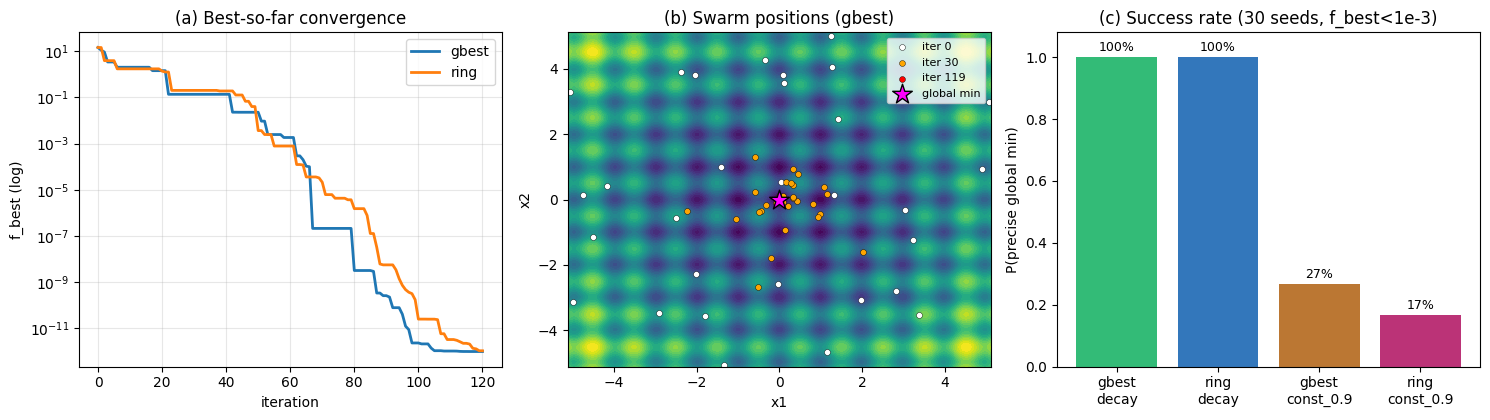

In [4]:
# ---- 시각화 ----
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))

# (a) 수렴 곡선
ax[0].semilogy(res_g["hist"] + 1e-12, label="gbest", lw=2)
ax[0].semilogy(res_r["hist"] + 1e-12, label="ring", lw=2)
ax[0].set_title("(a) Best-so-far convergence")
ax[0].set_xlabel("iteration"); ax[0].set_ylabel("f_best (log)")
ax[0].legend(); ax[0].grid(True, alpha=0.3)

# (b) 등고선 + 입자 분포 (gbest, 세 스냅샷)
gx = np.linspace(-BOUND, BOUND, 240)
GX, GY = np.meshgrid(gx, gx)
Z = (20 + (GX**2 - 10*np.cos(2*np.pi*GX)) + (GY**2 - 10*np.cos(2*np.pi*GY)))
ax[1].contourf(GX, GY, Z, levels=30, cmap="viridis")
colors = {0: "white", 30: "orange", 119: "red"}
for it, C in colors.items():
    S = res_g["snap"][it]
    ax[1].scatter(S[:, 0], S[:, 1], s=18, c=C, edgecolor="k",
                  linewidth=0.3, label=f"iter {it}")
ax[1].scatter([0], [0], marker="*", s=220, c="magenta", edgecolor="k", label="global min")
ax[1].set_title("(b) Swarm positions (gbest)")
ax[1].set_xlabel("x1"); ax[1].set_ylabel("x2"); ax[1].legend(fontsize=8)

# (c) 성공률 막대
labels = [f"{t}\n{w}" for t, w in zip(df_sr["topology"], df_sr["inertia"])]
ax[2].bar(labels, df_sr["success_rate"], color=["#33bb77", "#3377bb", "#bb7733", "#bb3377"])
ax[2].set_ylim(0, 1.08)
ax[2].set_title("(c) Success rate (30 seeds, f_best<1e-3)")
ax[2].set_ylabel("P(precise global min)")
for i, v in enumerate(df_sr["success_rate"]):
    ax[2].text(i, v + 0.02, f"{v:.0%}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

## 4. 결과 해석

> 성공 기준은 **$f_\text{best}<10^{-3}$**(전역최소 바닥까지 정밀 수렴)이다. 느슨한 위치 기준
> ($\lVert x\rVert$ 작음)으로는 네 설정 모두 전역 분지를 *찾기는* 하므로, 차이는 **바닥까지 다듬는
> 정밀도**에서 드러난다.

1. **(a) 수렴 속도** — *gbest* 는 단일 전역최선을 모두가 공유하므로 초반 하강이 **빠르다**. *ring* 은
   정보가 이웃을 통해 천천히 퍼져 초반은 느리지만 **다양성**을 더 오래 유지한다.
2. **(b) 군집 분포** — 초기(흰)에는 입자가 탐색공간 전체에 퍼져 있다가, 반복이 진행되며(주황→빨강)
   원점 근처 전역최소(★)로 **수축**한다. 관성 감소가 이 탐색→수렴 전환을 만든다.
3. **(c) 성공률** — **관성 감소($w:0.9\to0.4$)** 는 두 위상 모두 **성공률 100%**(평균 $f$ 가 $10^{-8}\!\sim\!
   10^{-15}$)인 반면, **고정 큰 관성($w{=}0.9$)** 은 후기에도 입자가 과하게 진동해 바닥을 못 다듬어
   성공률이 **gbest ~27% · ring ~17%** 로 급락한다(평균 $f\!\approx\!10^{-2}$). 즉 *전역 분지는 찾아도*
   정밀 수렴에는 **관성 감쇠가 결정적**이다.
4. **DE·SA 와의 관계** — PSO 는 DE 처럼 **개체군 기반**이지만 차분 벡터 대신 **개인/사회 인력**으로
   스텝을 만든다. SA 의 단일점 확률수락과 달리 군집의 **집단 기억**($\mathbf{p}_i,\mathbf{g}$)이 핵심이다.

> **결론**: *PSO 는 네 설정 모두 Rastrigin 의 전역 분지를 찾지만, 바닥까지의 정밀 수렴은 관성을
> 크게(탐색)→작게(활용) 줄이는 스케줄에 결정적으로 좌우된다 — 고정 큰 관성은 끝까지 진동해
> 갇힌다.*

**다음 문제로의 연결**: PSO·DE 는 난수 갱신식이 고정돼 있다. Problem 2 에서는 탐색 분포(공분산·보폭)를
**스스로 학습**하는 **CMA-ES** 로, 자기적응 진화전략의 정수를 구현한다.